# Báo Cáo : Phân Loại Rác Thải
**Hệ thống phân loại rác thải thông minh sử dụng (SVM + Ensemble)**

---
## Mục Lục
0. **Làm sạch và Chuẩn hóa Dữ liệu (Data Cleaning)** 
1. **Khám phá & Tiền xử lý Dữ liệu (EDA)** -- Phân tích phân phối, trực quan hóa, trích xuất đặc trưng
2. **Load Mô Hình Đã Train** -- Tải trực tiếp `svm_v2_model.pkl` và `best_ensemble_model.pkl`
3. **Đánh giá Chi Tiết** -- Confusion Matrix, Classification Report, phân tích lỗi


## PHẦN 1: Khám Phá & Tiền Xử Lý Dữ Liệu (EDA)

In [190]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Thiết lập font và style cho biểu đồ
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

DATASET_PATH = "../dataset/train"
classes = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))]
classes.sort()
print("Các nhãn (classes) trong dataset:", classes)

Các nhãn (classes) trong dataset: ['cardboard', 'glass', 'metal', 'organic', 'paper', 'plastic', 'trash']


## 2. Trực quan và Phân tích Dữ liệu (EDA)
### 2.1. Phân phối số lượng mẫu dữ liệu (Class Distribution)
**Ý nghĩa của bước này:**
Trước khi huấn luyện, ta bắt buộc phải đếm xem mỗi loại rác có bao nhiêu bức ảnh. Nếu một loại rác (VD: giấy) có tới 5000 ảnh, trong khi rác kim loại chỉ có 100 ảnh, mô hình sẽ bị "thiên vị" (Imbalanced Data) và luôn có xu hướng đoán là giấy. Việc vẽ biểu đồ cột giúp ta kiểm tra độ cân bằng của dữ liệu ngay từ đầu.

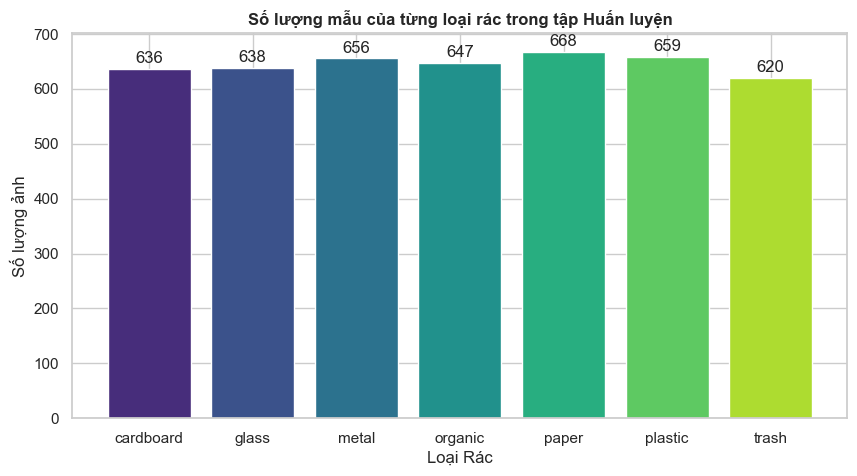

In [192]:
class_counts = []
for c in classes:
    count = len(os.listdir(os.path.join(DATASET_PATH, c)))
    class_counts.append(count)

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
bars = plt.bar(classes, class_counts, color=sns.color_palette("viridis", len(classes)))
plt.title('Số lượng mẫu của từng loại rác trong tập Huấn luyện', fontweight='bold')
plt.xlabel('Loại Rác')
plt.ylabel('Số lượng ảnh')

# Hiển thị số lượng trên đỉnh cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.show()

### 2.1b. Phân phối số lượng mẫu tập Validation & Test
**Ý nghĩa:** Ngoài tập Train, ta cần kiểm tra tập Validation (dùng để đánh giá trong quá trình huấn luyện) và tập Test (dùng để đánh giá cuối cùng) cũng phải có phân phối hợp lý, tránh mất cân bằng.

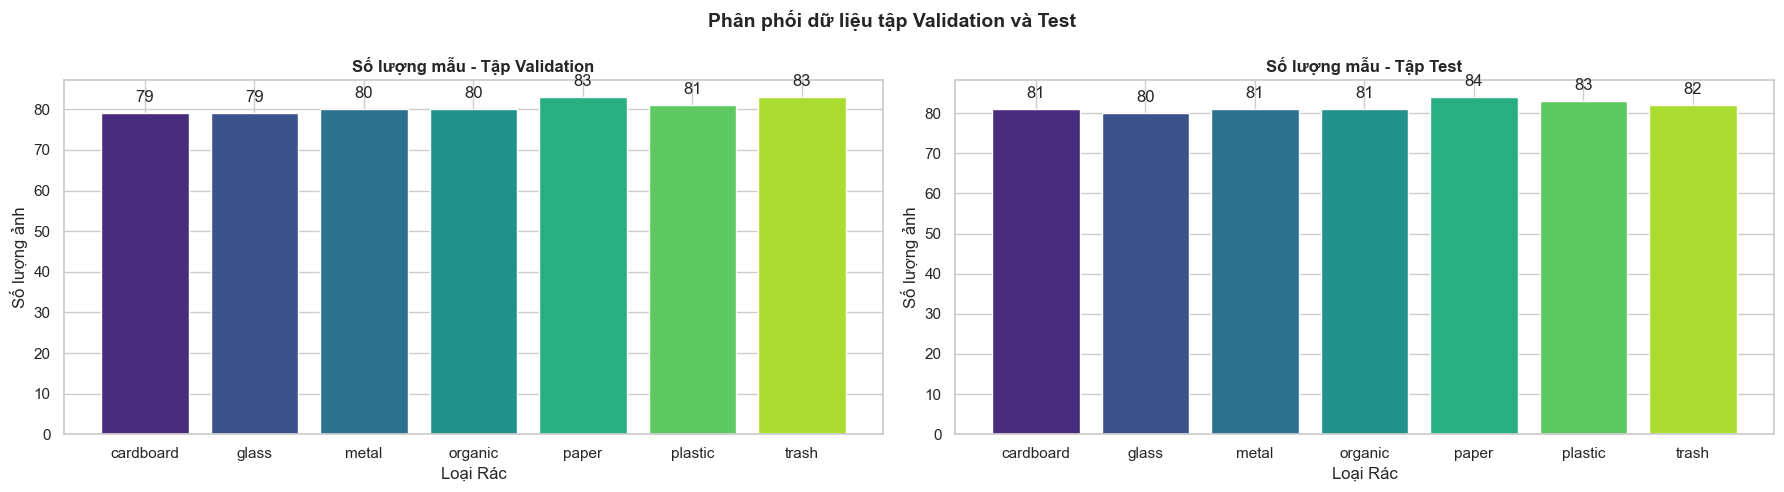


Tổng kết số lượng ảnh theo từng tập:
  Train       : 4518 ảnh
  Validation  : 565 ảnh
  Test        : 572 ảnh


In [194]:
# Vẽ biểu đồ phân phối cho tập Validation và Test
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for idx, (split_name, split_path) in enumerate([('Validation', '../dataset/validation'), ('Test', '../dataset/test')]):
    counts = []
    for c in classes:
        p = os.path.join(split_path, c)
        if os.path.exists(p):
            counts.append(len([f for f in os.listdir(p) if f.lower().endswith(('.png','.jpg','.jpeg'))]))
        else:
            counts.append(0)
    
    # Vẽ biểu đồ cột cho từng tập dữ liệu
    bars = axes[idx].bar(classes, counts, color=sns.color_palette('viridis', len(classes)))
    axes[idx].set_title(f'Số lượng mẫu - Tập {split_name}', fontweight='bold')
    axes[idx].set_xlabel('Loại Rác')
    axes[idx].set_ylabel('Số lượng ảnh')
    
    # Hiển thị số lượng trên đỉnh cột
    for bar in bars:
        yval = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2, yval + 2, int(yval), ha='center', va='bottom')

plt.suptitle('Phân phối dữ liệu tập Validation và Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# In bảng tổng kết số lượng ảnh của cả 3 tập
print('\nTổng kết số lượng ảnh theo từng tập:')
for split_name, split_path in [('Train', '../dataset/train'), ('Validation', '../dataset/validation'), ('Test', '../dataset/test')]:
    total = 0
    for c in classes:
        p = os.path.join(split_path, c)
        if os.path.exists(p):
            total += len([f for f in os.listdir(p) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    print(f'  {split_name:12s}: {total} ảnh')

### 2.2. Trực quan hóa dữ liệu gốc (Sanity Check)
**Ý nghĩa của bước này:**
Không thể nhắm mắt tin tưởng hoàn toàn vào nguồn dữ liệu tải trên mạng. Việc in ngẫu nhiên vài bức ảnh ra màn hình là bước "kiểm tra bằng mắt thường" (Sanity Check) để đảm bảo hình ảnh không bị lỗi hỏng, đúng nhãn (không có chuyện thư mục `plastic` nhưng lại chứa ảnh chó mèo).

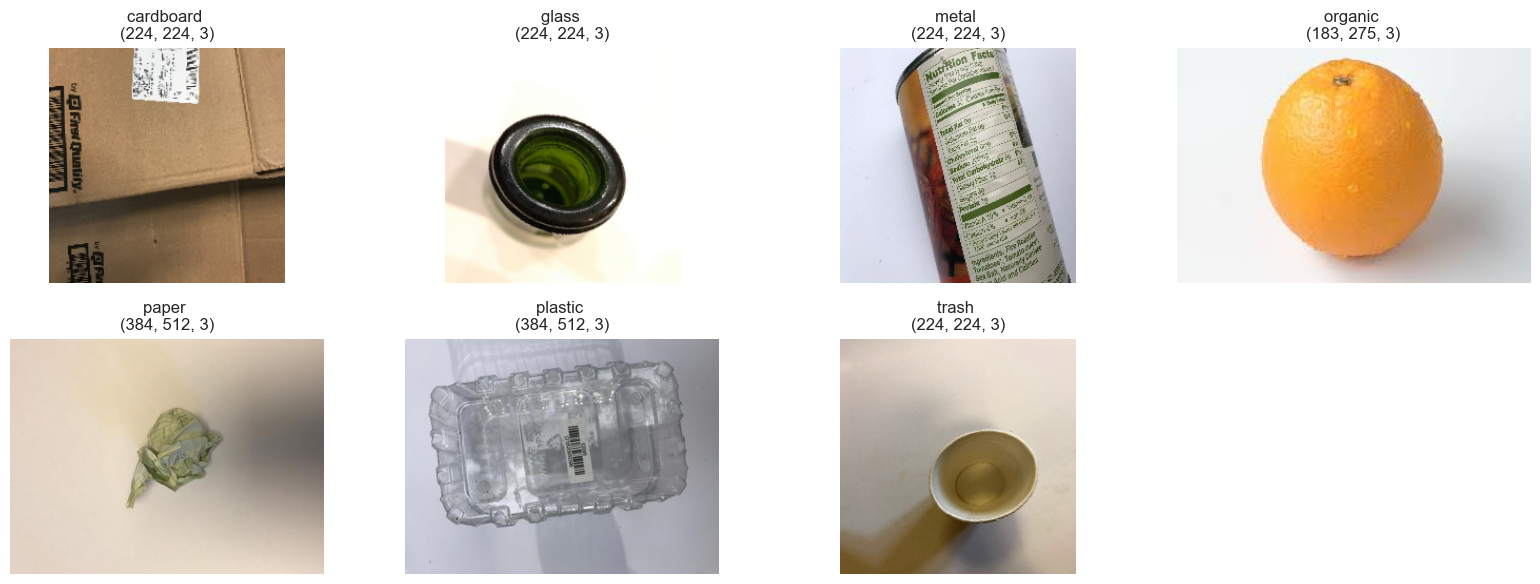

In [196]:
plt.figure(figsize=(16, 6))
for i, cls in enumerate(classes):
    cls_path = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if not images: continue
        
    img_path = os.path.join(cls_path, random.choice(images))
    
    # OpenCV đọc ảnh theo hệ BGR, ta cần chuyển sang RGB để plt hiển thị đúng màu
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"{cls} \n{img_rgb.shape}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 3. Tiền xử lý (Preprocessing) & Trích xuất Đặc trưng
**Tư duy thuật toán:**
Máy tính (như mô hình SVM, KNN) KHÔNG nhìn được bức ảnh như con người. Nó chỉ hiểu một mảng các con số (Vector 1 chiều). Nhiệm vụ của Tiền xử lý là phải trích xuất ra các "đặc điểm" nổi bật nhất của bức ảnh (màu sắc, hình khối) và biến chúng thành các con số toán học.

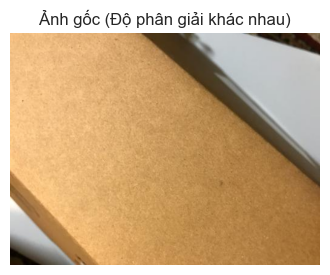

In [198]:
# Lấy 1 ảnh bất kỳ làm ví dụ
sample_class = classes[0]
sample_files = os.listdir(os.path.join(DATASET_PATH, sample_class))
sample_img_path = os.path.join(DATASET_PATH, sample_class, sample_files[0])

# 1. Đọc và chuyển đổi màu RGB
raw_img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4, 4))
plt.imshow(img_rgb)
plt.title("Ảnh gốc (Độ phân giải khác nhau)")
plt.axis('off')
plt.show()

### Bước 3.1. Đưa về kích thước chuẩn (Resize)
**Ý nghĩa của bước này:**
Ảnh trong thực tế có kích thước lộn xộn (4K, Full HD, ảnh vuông, ảnh dọc). Ta bắt buộc phải ép tất cả ảnh về chung một kích thước (ví dụ `64x64`) thì thuật toán mới nhận đầu vào có cùng số lượng chiều (dimension) được.

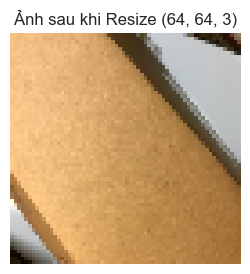

In [200]:
img_resized = cv2.resize(img_rgb, (64, 64))

plt.figure(figsize=(3, 3))
plt.imshow(img_resized)
plt.title(f"Ảnh sau khi Resize {img_resized.shape}")
plt.axis('off')
plt.show()

### Bước 3.2. Trích xuất đặc trưng Cấu trúc (Small Pixels)
**Ý nghĩa của bước này:**
Làm sao để máy tính biết rác nilon thường nhàu nhĩ, còn bìa carton thường vuông vức? Chúng ta ép bức ảnh `64x64` thu nhỏ lại thành lưới cực nhỏ `8x8`. Thao tác này có ý nghĩa cực lớn: Nó làm mờ đi các chi tiết chữ viết, hoa văn thừa thãi, chỉ giữ lại ĐƯỜNG NÉT TỔNG QUAN của rác. Sau đó ta trải phẳng lưới 8x8 thành một mảng 64 số (từ 0-1).

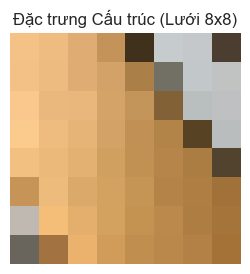

Vector cấu trúc có độ dài: 192 chiều


In [202]:
small_img = cv2.resize(img_resized, (8, 8))# x3 kênh màu RGB =192 chiều
small_features = small_img.flatten() / 255.0  # Chuẩn hóa về [0, 1]

plt.figure(figsize=(3, 3))
plt.imshow(small_img)
plt.title("Đặc trưng Cấu trúc (Lưới 8x8)")
plt.axis('off')
plt.show()

print(f"Vector cấu trúc có độ dài: {len(small_features)} chiều")

### Bước 3.3. Trích xuất Đặc trưng Màu sắc (HSV Histogram)
**Ý nghĩa của bước này:**
Rác hữu cơ thường có màu xanh lục/nâu, thủy tinh thường có xanh lam. Màu sắc là chìa khóa phân loại. Tuy nhiên, thay vì dùng hệ màu RGB (Red Green Blue) rất dễ bị ảnh hưởng bởi ánh sáng môi trường (sáng sớm hay chiều tối), ta chuyển ảnh sang **hệ màu HSV**. HSV bóc tách riêng biệt "Độ sáng" ra khỏi "Màu sắc gốc", giúp chống nhiễu ánh sáng cực tốt. Sau đó ta đếm tần suất xuất hiện của các dải màu tạo thành 3 biểu đồ (Histogram).

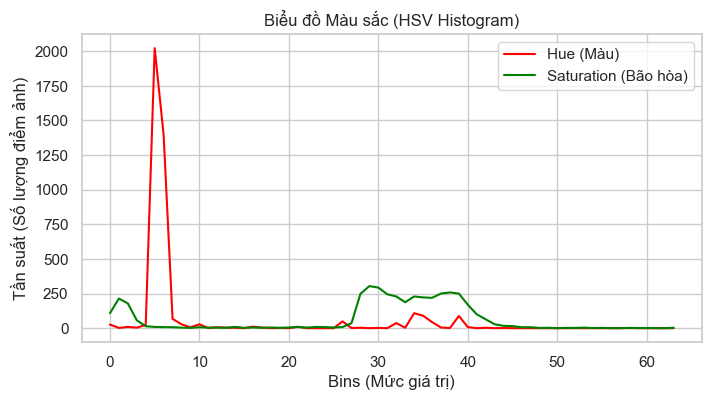

Vector màu sắc có độ dài: 192 chiều


In [204]:
hsv = cv2.cvtColor(img_resized, cv2.COLOR_RGB2HSV)
# chuyển hệ màu từ RGB sang HSV
# Tính Histogram cho kênh Hue (Màu sắc), Saturation (Độ bão hòa), Value (Độ sáng)
# Sử dụng 64 bins để có độ chi tiết cao
h_hist = cv2.calcHist([hsv], [0], None, [64], [0, 180])
s_hist = cv2.calcHist([hsv], [1], None, [64], [0, 256])
v_hist = cv2.calcHist([hsv], [2], None, [64], [0, 256])

# Vẽ biểu đồ Màu sắc (Hue)
plt.figure(figsize=(8, 4))
plt.plot(h_hist, color='red', label='Hue (Màu)')
plt.plot(s_hist, color='green', label='Saturation (Bão hòa)')
plt.title("Biểu đồ Màu sắc (HSV Histogram)")
plt.xlabel("Bins (Mức giá trị)")
plt.ylabel("Tần suất (Số lượng điểm ảnh)")
plt.legend()
plt.show()

# Nối 3 biểu đồ lại thành 1 vector duy nhất
color_features = np.concatenate([h_hist, s_hist, v_hist]).flatten()
cv2.normalize(color_features, color_features)
print(f"Vector màu sắc có độ dài: {len(color_features)} chiều")

### Bước 3.4. Ghép Đặc trưng & Chuẩn hóa (Standardization)
**Ý nghĩa của bước này:**
Ghép 2 vector (Cấu trúc + Màu sắc) lại thành 1. Tuy nhiên, các đặc trưng đang có thang đo "lệch pha" nhau (có cái thì giá trị bé xíu từ 0-1, có cái lại là số lượng điểm ảnh to đùng hàng trăm). Nếu ném thẳng vào mô hình SVM (vốn đo lường bằng khoảng cách toán học), số lớn sẽ "đè bẹp" số nhỏ, làm AI bị sai lệch trầm trọng.

**Giải pháp:** Áp dụng `StandardScaler` để ép toàn bộ dữ liệu về chung một hệ quy chiếu Công bằng (Trung bình $\mu=0$, Độ lệch chuẩn $\sigma=1$). Dưới đây là bằng chứng trực quan:

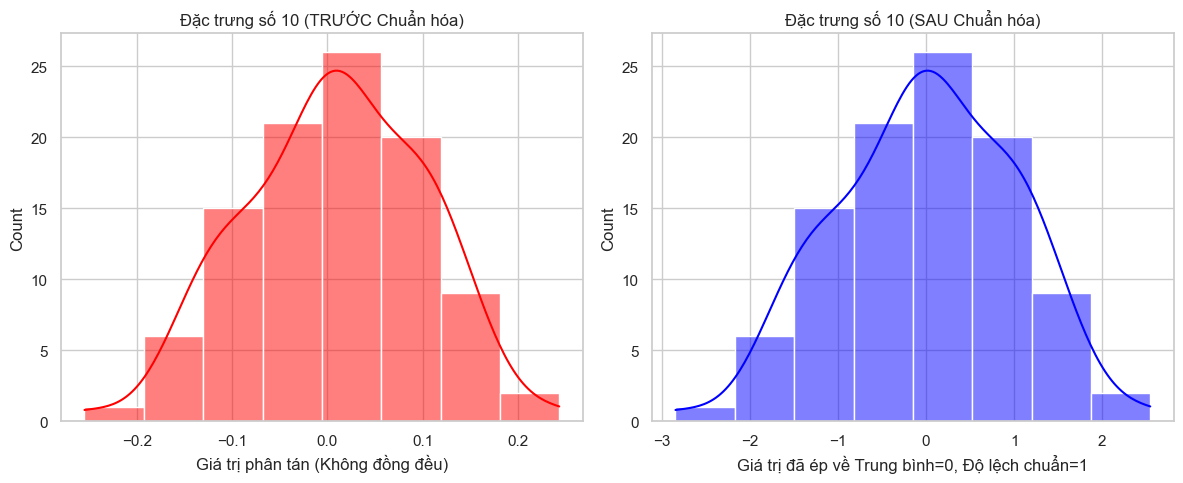

🎯 TỔNG KẾT BƯỚC 1: Mỗi bức ảnh khổng lồ nay đã được biểu diễn bởi một Vector 384 chiều toán học.
Quá trình Tiền xử lý hoàn tất! Dữ liệu đã SẠCH, CHUẨN và SẴN SÀNG để tiến vào Bước 2: Huấn luyện Mô hình.


In [17]:
from sklearn.preprocessing import StandardScaler

final_features = np.concatenate([color_features, small_features])

# Giả lập một tập dữ liệu gồm 100 bức ảnh (bằng cách thêm nhiễu ngẫu nhiên vào vector gốc)
X_dummy = np.array([final_features + np.random.normal(0, 0.1, len(final_features)) for _ in range(100)])

# Áp dụng StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_dummy)

# Trực quan hóa so sánh sự thay đổi của Đặc trưng số 10 (ví dụ)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(X_dummy[:, 10], kde=True, color='red')
plt.title("Đặc trưng số 10 (TRƯỚC Chuẩn hóa)")
plt.xlabel("Giá trị phân tán (Không đồng đều)")

plt.subplot(1, 2, 2)
sns.histplot(X_scaled[:, 10], kde=True, color='blue')
plt.title("Đặc trưng số 10 (SAU Chuẩn hóa)")
plt.xlabel("Giá trị đã ép về Trung bình=0, Độ lệch chuẩn=1")

plt.tight_layout()
plt.show()

print(f"🎯 TỔNG KẾT BƯỚC 1: Mỗi bức ảnh khổng lồ nay đã được biểu diễn bởi một Vector {len(final_features)} chiều toán học.")
print("Quá trình Tiền xử lý hoàn tất! Dữ liệu đã SẠCH, CHUẨN và SẴN SÀNG để tiến vào Bước 2: Huấn luyện Mô hình.")

---
## PHẦN 2: Tải Mô Hình Đã Huấn Luyện
> Không cần train lại! Chỉ cần load file `.pkl` đã được lưu sẵn từ quá trình huấn luyện.

In [212]:
import os, sys, cv2, numpy as np, joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.notebook import tqdm

# Thiết lập đường dẫn project root (lùi về 1 cấp từ notebooks/)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Import cấu hình lớp rác và hàm trích xuất đặc trưng
from src.core.config import CLASSES
from src.scripts.feature_utils import extract_features

# Kích thước ảnh chuẩn khi trích xuất đặc trưng
IMG_SIZE = (64, 64)

# Đường dẫn 2 model đã train sẵn
SVM_MODEL_PATH      = os.path.join(project_root, 'outputs', 'svm_results', 'svm_v2_model.pkl')
ENSEMBLE_MODEL_PATH = os.path.join(project_root, 'outputs', 'ensemble_results', 'best_ensemble_model.pkl')

# Kiểm tra xem file model có tồn tại không
def check_model(path, name):
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024 / 1024
        print(f'  [OK] {name} -- {size_mb:.1f} MB -- {path}')
    else:
        print(f'  [THIEU] Chưa tìm thấy: {path}')

print('Kiểm tra model đã train:')
check_model(SVM_MODEL_PATH, 'SVM V2')
check_model(ENSEMBLE_MODEL_PATH, 'Ensemble (Soft Voting)')

Kiểm tra model đã train:
  [OK] SVM V2 -- 164.0 MB -- /Users/nguyenvan/AI_ML/CLASSIFICATION/outputs/svm_results/svm_v2_model.pkl
  [OK] Ensemble (Soft Voting) -- 407.0 MB -- /Users/nguyenvan/AI_ML/CLASSIFICATION/outputs/ensemble_results/best_ensemble_model.pkl


### Load tập Validation để đánh giá
Sử dụng vòng lặp tuần tự (không dùng multiprocessing) để tương thích với Jupyter Notebook.

In [214]:
def load_val_data(data_dir):
    """
    Trích xuất đặc trưng từ toàn bộ ảnh trong tập validation.
    Trả về X (mảng features), y (mảng nhãn lớp).
    Không sử dụng multiprocessing để tương thích với Jupyter.
    """
    X, y = [], []
    print(f'Đang tải tập Validation từ: {data_dir}')
    
    for class_idx, class_name in enumerate(CLASSES):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.exists(class_path):
            continue
        
        # Lọc chỉ lấy file ảnh (png, jpg, jpeg)
        files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
        
        # Duyệt từng file ảnh, trích xuất đặc trưng
        for f in tqdm(files, desc=f'{class_name:15s}'):
            try:
                img = cv2.imread(os.path.join(class_path, f))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)       # Chuyển từ BGR sang RGB
                img = cv2.resize(img, IMG_SIZE)                   # Resize về kích thước chuẩn
                feat = extract_features(img, use_grabcut=False)   # Trích xuất HSV + HOG + LBP
                X.append(feat)
                y.append(class_idx)
            except Exception:
                continue
    
    return np.array(X, dtype=np.float32), np.array(y)

# Đường dẫn tập validation
val_dir = os.path.join(project_root, 'dataset', 'validation')

# Gọi hàm load dữ liệu
X_val, y_val = load_val_data(val_dir)
print(f'\nLoad xong: {len(X_val)} ảnh validation.')

Đang tải tập Validation từ: /Users/nguyenvan/AI_ML/CLASSIFICATION/dataset/validation


cardboard      :   0%|          | 0/79 [00:00<?, ?it/s]

glass          :   0%|          | 0/79 [00:00<?, ?it/s]

metal          :   0%|          | 0/80 [00:00<?, ?it/s]

organic        :   0%|          | 0/80 [00:00<?, ?it/s]

paper          :   0%|          | 0/83 [00:00<?, ?it/s]

plastic        :   0%|          | 0/81 [00:00<?, ?it/s]

trash          :   0%|          | 0/83 [00:00<?, ?it/s]


Load xong: 565 ảnh validation.


---
## PHẦN 3: Đánh Giá Chi Tiết Các Mô Hình


  ĐÁNH GIÁ MÔ HÌNH: SVM V2 (HSV + HOG + LBP)

  Độ chính xác (Accuracy): 83.72%
  Số ảnh đúng: 472/565

Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

   cardboard       0.89      0.95      0.92        79
       glass       0.69      0.72      0.70        79
       metal       0.82      0.81      0.82        80
     organic       0.97      0.96      0.97        80
       paper       0.81      0.84      0.83        83
     plastic       0.78      0.72      0.75        81
       trash       0.89      0.86      0.87        83

    accuracy                           0.84       565
   macro avg       0.84      0.84      0.84       565
weighted avg       0.84      0.84      0.84       565



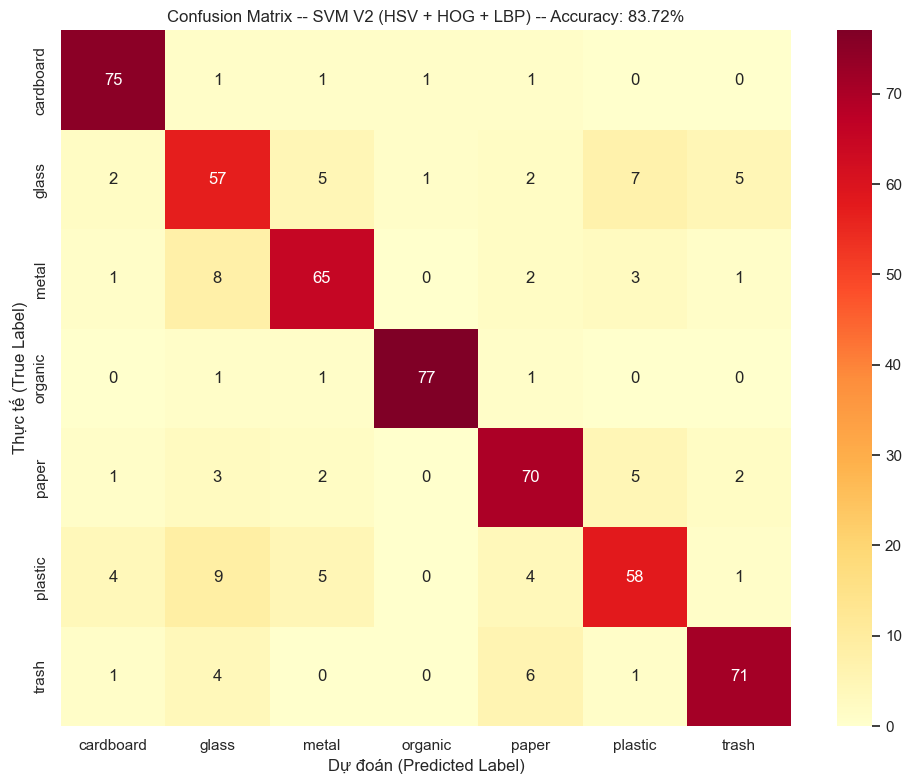

In [216]:
from sklearn.metrics import accuracy_score

def evaluate_model(model_path, model_name):
    """
    Load model từ file .pkl, dự đoán trên tập validation,
    in Accuracy, Classification Report và vẽ Confusion Matrix.
    """
    if not os.path.exists(model_path):
        print(f'Không tìm thấy: {model_path}')
        return None, None
    
    # Load model và scaler từ file pkl
    bundle  = joblib.load(model_path)
    model   = bundle['model']    # Mô hình đã train
    scaler  = bundle['scaler']   # Bộ chuẩn hóa StandardScaler
    
    # Chuẩn hóa dữ liệu validation bằng scaler đã fit trên tập train
    X_scaled = scaler.transform(X_val)
    
    # Dự đoán nhãn cho toàn bộ tập validation
    y_pred = model.predict(X_scaled)

    # Tính độ chính xác (Accuracy)
    acc = accuracy_score(y_val, y_pred)

    print(f'\n{"="*55}')
    print(f'  ĐÁNH GIÁ MÔ HÌNH: {model_name}')
    print(f'{"="*55}')
    print(f'\n  Độ chính xác (Accuracy): {acc*100:.2f}%')
    print(f'  Số ảnh đúng: {int(acc*len(y_val))}/{len(y_val)}')

    # In báo cáo phân loại (Precision, Recall, F1-Score)
    print(f'\nBáo cáo phân loại chi tiết (Classification Report):')
    print(classification_report(y_val, y_pred, target_names=CLASSES))

    # Vẽ Confusion Matrix (Ma trận nhầm lẫn)
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=CLASSES, yticklabels=CLASSES, cmap='YlOrRd')
    plt.title(f'Confusion Matrix -- {model_name} -- Accuracy: {acc*100:.2f}%')
    plt.ylabel('Thực tế (True Label)')
    plt.xlabel('Dự đoán (Predicted Label)')
    plt.tight_layout()
    plt.show()
    
    return model, scaler

# Đánh giá SVM V2
svm_model, svm_scaler = evaluate_model(SVM_MODEL_PATH, 'SVM V2 (HSV + HOG + LBP)')


  ĐÁNH GIÁ MÔ HÌNH: Soft Voting Ensemble (SVM + RF + KNN)

  Độ chính xác (Accuracy): 86.19%
  Số ảnh đúng: 487/565

Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

   cardboard       0.89      0.94      0.91        79
       glass       0.81      0.77      0.79        79
       metal       0.84      0.80      0.82        80
     organic       0.95      0.96      0.96        80
       paper       0.80      0.87      0.83        83
     plastic       0.84      0.80      0.82        81
       trash       0.89      0.89      0.89        83

    accuracy                           0.86       565
   macro avg       0.86      0.86      0.86       565
weighted avg       0.86      0.86      0.86       565



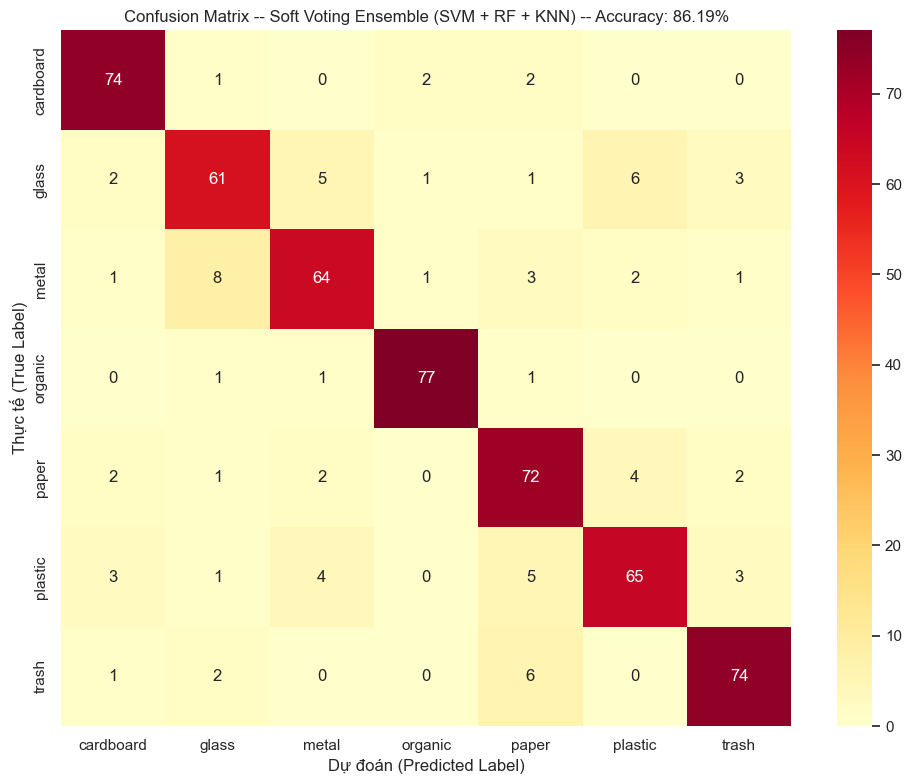

In [217]:
# Đánh giá Ensemble V2
ens_model, ens_scaler = evaluate_model(ENSEMBLE_MODEL_PATH, 'Soft Voting Ensemble (SVM + RF + KNN)')

### Phân tích lỗi -- Hiển thị 5 ảnh dự đoán SAI

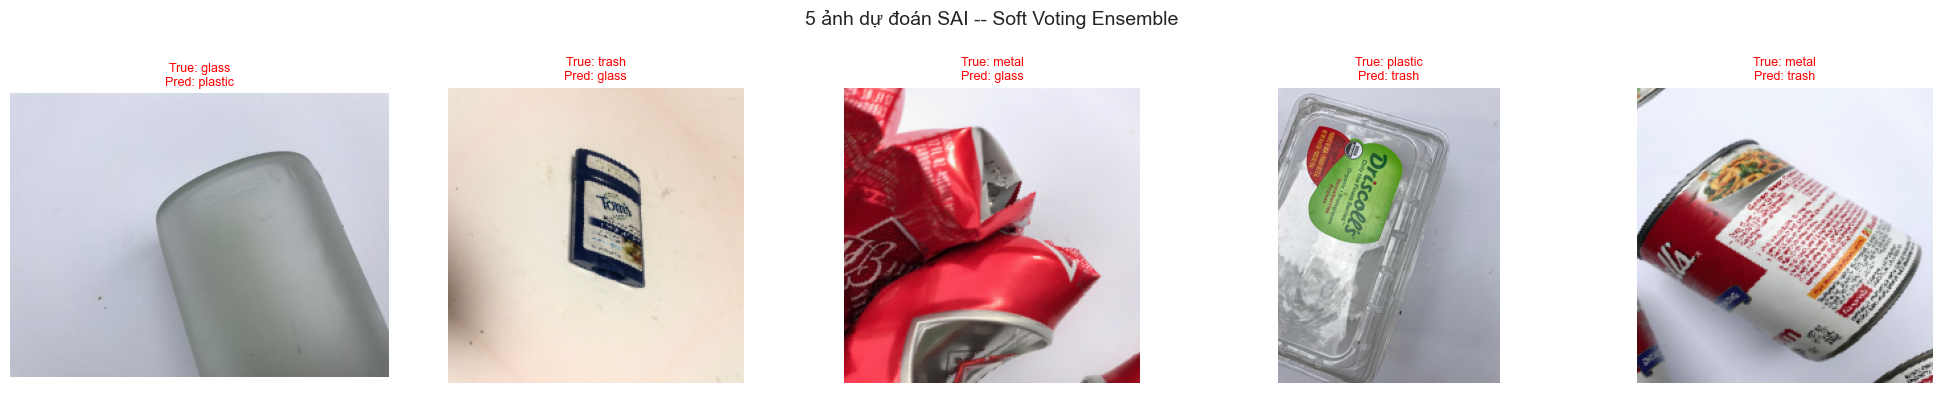

In [219]:
import random

def show_mistakes(model, scaler, title='Model'):
    """
    Tìm các ảnh bị dự đoán sai, hiển thị ngẫu nhiên 5 ảnh
    kèm nhãn thực tế và nhãn dự đoán để phân tích lỗi.
    """
    # Chuẩn hóa và dự đoán
    X_scaled = scaler.transform(X_val)
    y_pred   = model.predict(X_scaled)
    
    # Tìm chỉ số (index) của các ảnh bị dự đoán sai
    wrong = np.where(y_pred != y_val)[0]
    if len(wrong) == 0:
        print('Không có ảnh nào đoán sai!')
        return

    # Chọn ngẫu nhiên tối đa 5 ảnh sai
    sample = random.sample(list(wrong), min(5, len(wrong)))

    # Lấy toàn bộ đường dẫn ảnh validation theo thứ tự
    val_files = []
    for cls in CLASSES:
        p = os.path.join(val_dir, cls)
        if os.path.exists(p):
            val_files += sorted([
                os.path.join(p, f)
                for f in os.listdir(p)
                if f.lower().endswith(('.png','.jpg','.jpeg'))
            ])

    # Vẽ 5 ảnh sai lên 1 hàng
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f'5 ảnh dự đoán SAI -- {title}', fontsize=14)
    
    for idx, ax in zip(sample, axes):
        img = cv2.cvtColor(cv2.imread(val_files[idx]), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(
            f'True: {CLASSES[y_val[idx]]}\nPred: {CLASSES[y_pred[idx]]}',
            color='red', fontsize=9
        )
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Hiển thị các ảnh sai của Ensemble
if ens_model:
    show_mistakes(ens_model, ens_scaler, 'Soft Voting Ensemble')